In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import seaborn as sns

In [2]:
df = pd.read_csv("data//hotels.csv")

In [13]:
X = df[['Sqrm', 'Revenue', 'City']]
y = df['Price in Mio']

X = pd.get_dummies(X)
X = X[['Sqrm', 'Revenue', 'City_Berlin', 'City_Köln', 'City_München']].astype(int)
X, y

(     Sqrm  Revenue  City_Berlin  City_Köln  City_München
 0    3938   119000            1          0             0
 1    3986   250000            0          0             1
 2    2574   250000            0          1             0
 3    4155   145000            0          0             1
 4    3795   110000            1          0             0
 ..    ...      ...          ...        ...           ...
 145  1775    45000            0          1             0
 146  4058   250000            0          1             0
 147  1668    32000            1          0             0
 148  2281    35000            1          0             0
 149  2297    90000            1          0             0
 
 [150 rows x 5 columns],
 0      21.88
 1      27.95
 2      16.09
 3      27.58
 4      23.76
        ...  
 145    10.50
 146    23.80
 147    12.86
 148    15.80
 149    17.09
 Name: Price in Mio, Length: 150, dtype: float64)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
model.coef_, model.intercept_
y_pred = model.predict(X_test)

In [18]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, rmse, mae, mape, r2

(1.190490607381336,
 np.float64(1.0910960578158717),
 0.8939801164153872,
 0.07602120501646975,
 0.969371781842238)

In [36]:
X_test['y_pred'] = y_pred
X_test['y_test'] = y_test
X_test['delta'] = y_pred - y_test

In [37]:
X_test

,Sqrm,Revenue,City_Berlin,City_Köln,City_München,y_pred,y_test,delta
54,2630,99000,0,0,1,20.609484,21.26,-0.650516
92,3165,80000,0,1,0,16.826547,17.13,-0.303453
27,525,250000,0,1,0,8.169701,6.73,1.439701
75,4436,250000,0,0,1,29.052838,27.94,1.112838
122,3309,125000,1,0,0,20.170194,21.27,-1.099806
144,3078,159000,1,0,0,19.593118,21.40,-1.806882
147,1668,32000,1,0,0,12.915204,12.86,0.055204
29,1497,32000,0,0,1,15.574087,17.22,-1.645913
48,2101,101000,0,1,0,12.889386,11.87,1.019386
99,1594,39000,1,0,0,12.693630,13.98,-1.286370


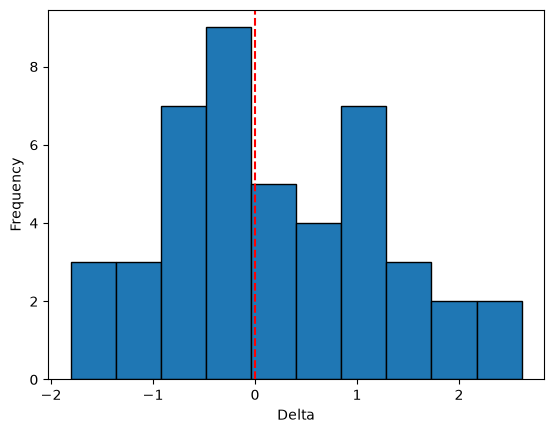

In [42]:
plt.hist(X_test['delta'], bins=10, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Delta')
plt.ylabel('Frequency')
plt.show()